# Init

In [1]:
%reload_ext autoreload
%autoreload 2

%config InlineBackend.figure_format = 'retina' # High-resolution plot outputs for Retina laptops

In [2]:
# Externals
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

# Input data

In [3]:
brightness_4K_monitor = np.array([4,
                                  18, 31, 46, 64,
                                  84, 108, 137, 169,
                                  206, 249, 297, 351,
                                  412, 480, 557, 644])

brightness_5K_monitor = np.array([3,
                                  17, 29, 44, 62,
                                  82, 106, 134, 166,
                                  202, 244, 290, 343,
                                  402, 468, 542, 628])

x = np.arange(0, len(brightness_4K_monitor))

mbp_min = 5
mbp_max = 530

brightness_mbp = np.array([mbp_min, mbp_max])
x_mbp = np.array([0, 16])

# Plot input

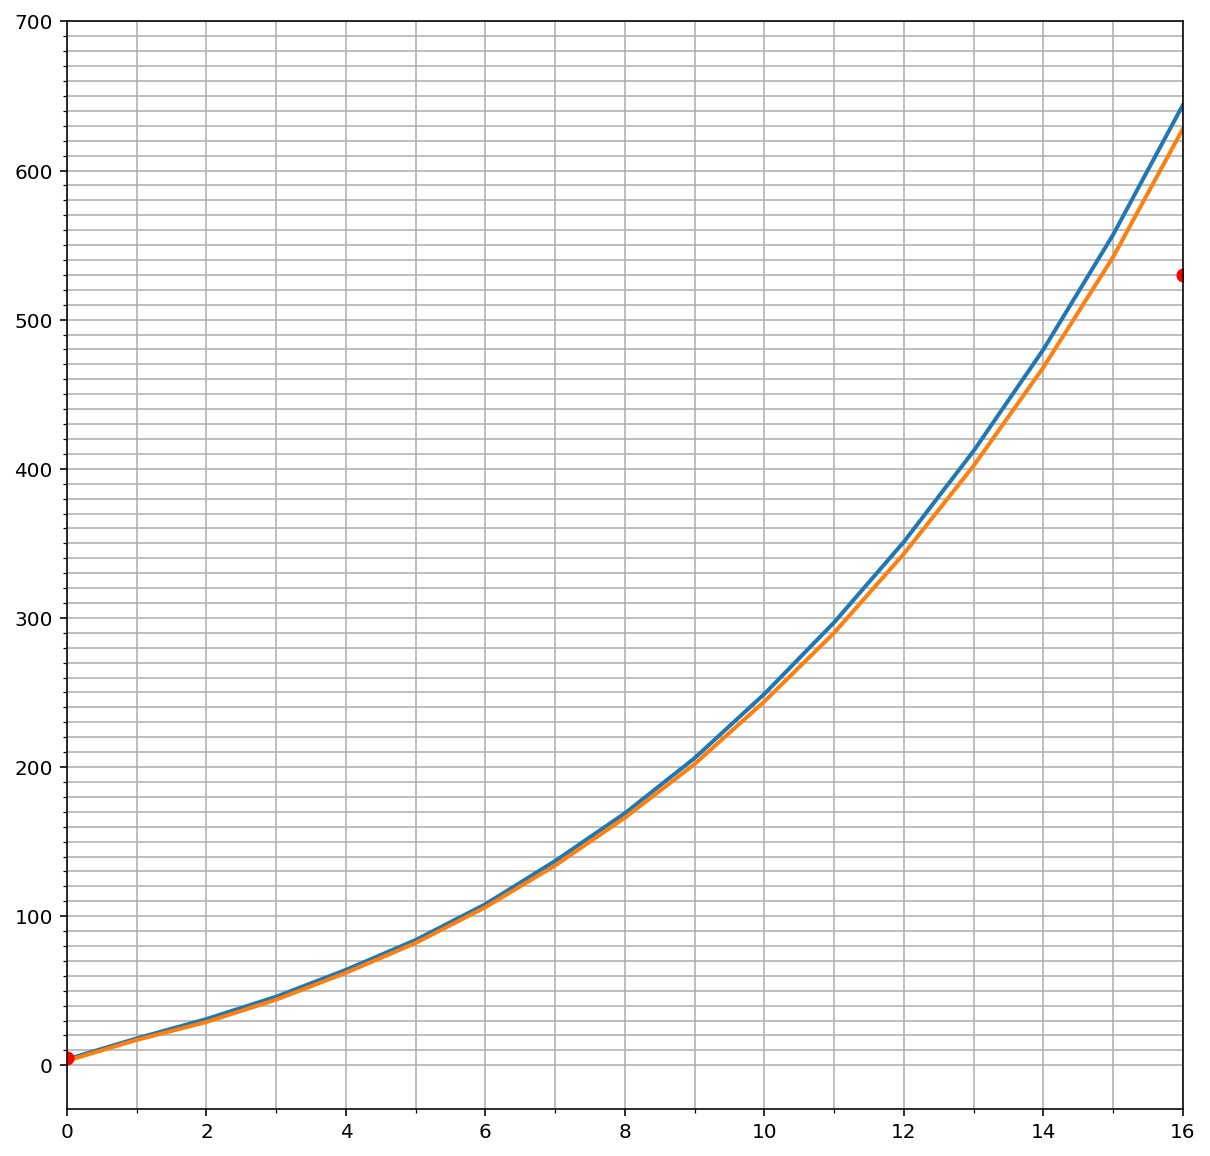

In [38]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(x, brightness_4K_monitor, lw=2.0)
ax.plot(x, brightness_5K_monitor, lw=2.0)
ax.plot(x_mbp, brightness_mbp, 'ro')
ax.set_xticks(np.arange(0, 16, 1), minor=True)
ax.set_yticks(np.arange(0, 710, 10), minor=True)
ax.grid(which='both')
ax.autoscale(axis="x", tight=True)
plt.show()

In [24]:
np.arange(0, 16)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

# Model

## Exponential function

$$ y = f(x, a, b, c) = a\cdot e^{b \cdot x} + c $$

In [5]:
def f(x, a, b, c):
    return a * np.exp(b * x) + c
popt, pcov = curve_fit(f, x, brightness_4K_monitor)
popt

array([ 92.60968854,   0.12966392, -90.41529936])

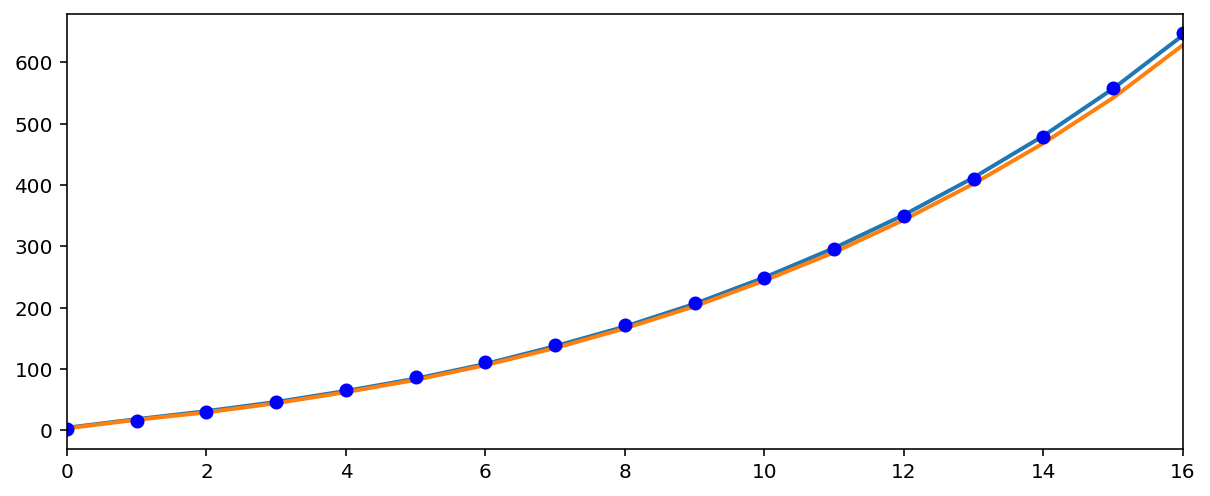

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(x, brightness_4K_monitor, lw=2.0)
plt.plot(x, brightness_5K_monitor, lw=2.0)
plt.plot(x, f(x, *popt), 'bo')
plt.autoscale(axis="x", tight=True)
plt.show()

## Logarithmic function

$$ y = a\cdot ln(b\cdot x) + c $$

In [7]:
def f(x, a, b, c):
    return a * np.log(b * x) + c
popt, pcov = curve_fit(f, x[1:], brightness_4K_monitor[1:])
popt

/Users/ilirium/opt/anaconda3/envs/geo_structured/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log
  


array([208.64583297,   0.70076815, -84.97014861])

/Users/ilirium/opt/anaconda3/envs/geo_structured/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log
  


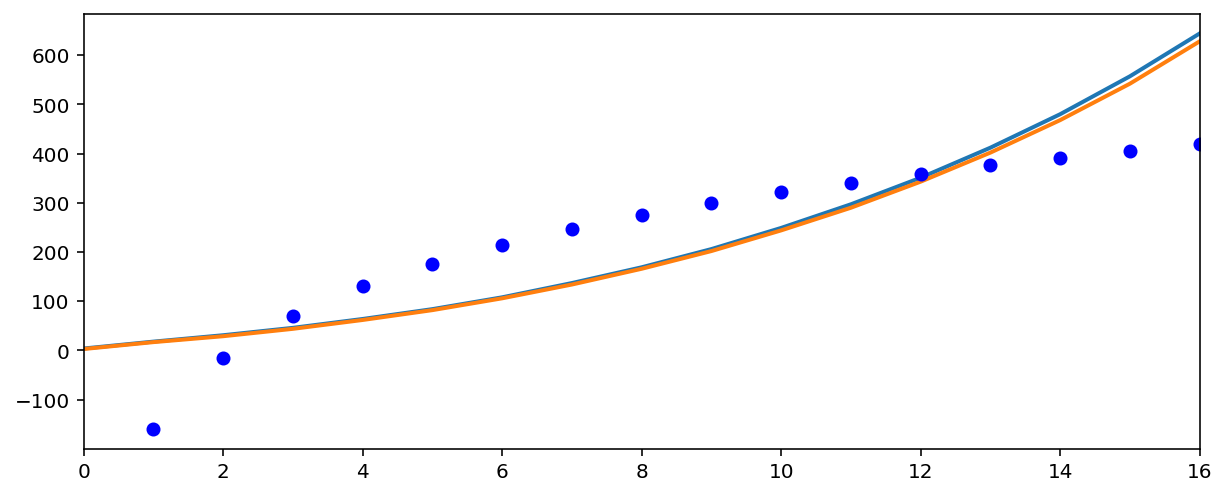

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(x, brightness_4K_monitor, lw=2.0)
plt.plot(x, brightness_5K_monitor, lw=2.0)
plt.plot(x, f(x, *popt), 'bo')
plt.autoscale(axis="x", tight=True)
plt.show()

## Power function, x as exponent

$$ y = a\cdot b^x + c $$

In [9]:
def f(x, a, b, c):
    return a * np.power(b, x) + c
popt, pcov = curve_fit(f, x, brightness_4K_monitor)
popt

array([ 92.60968909,   1.13844571, -90.41530015])

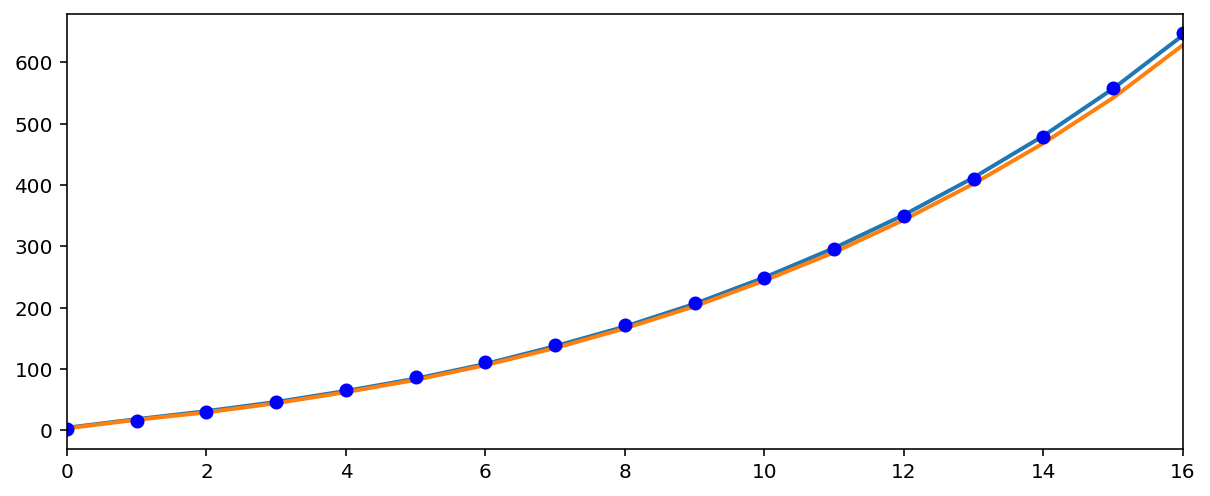

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(x, brightness_4K_monitor, lw=2.0)
plt.plot(x, brightness_5K_monitor, lw=2.0)
plt.plot(x, f(x, *popt), 'bo')
plt.autoscale(axis="x", tight=True)
plt.show()

## Power function, b as exponent

$$ y = a\cdot x^b + c $$

In [11]:
def f(x, a, b, c):
    return a * np.power(x, b) + c
popt, pcov = curve_fit(f, x, brightness_4K_monitor)
popt

array([ 1.91941078,  2.07891237, 21.5662867 ])

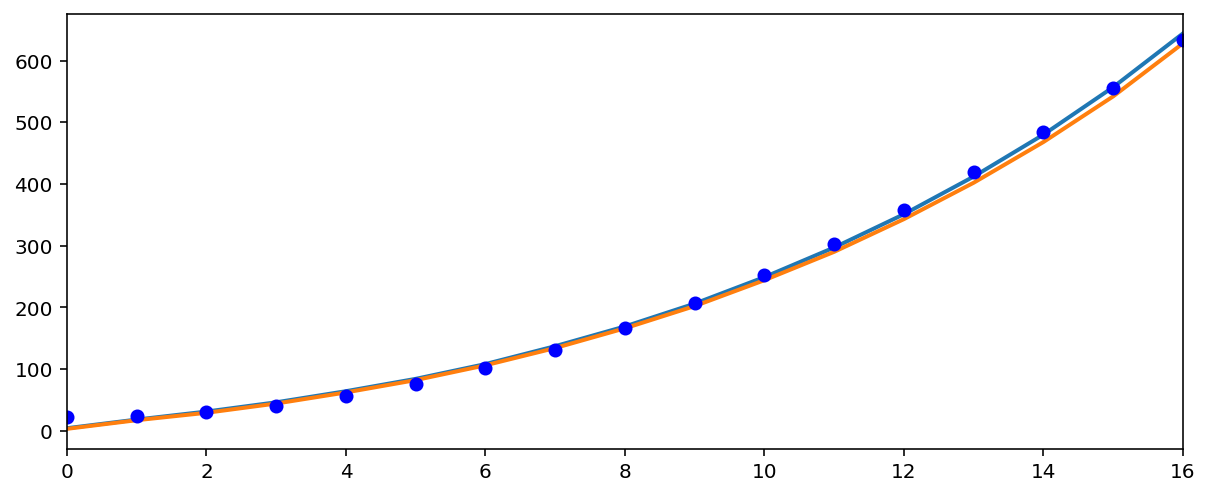

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(x, brightness_4K_monitor, lw=2.0)
plt.plot(x, brightness_5K_monitor, lw=2.0)
plt.plot(x, f(x, *popt), 'bo')
plt.autoscale(axis="x", tight=True)
plt.show()

# Exponential as model

## `a` and `b`

In [13]:
def f(x, a, b):
    return a * np.exp(b * x)
popt, pcov = curve_fit(f, x_mbp, brightness_mbp)
popt

/Users/ilirium/opt/anaconda3/envs/geo_structured/lib/python3.7/site-packages/scipy/optimize/minpack.py:808: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


array([5.        , 0.29146494])

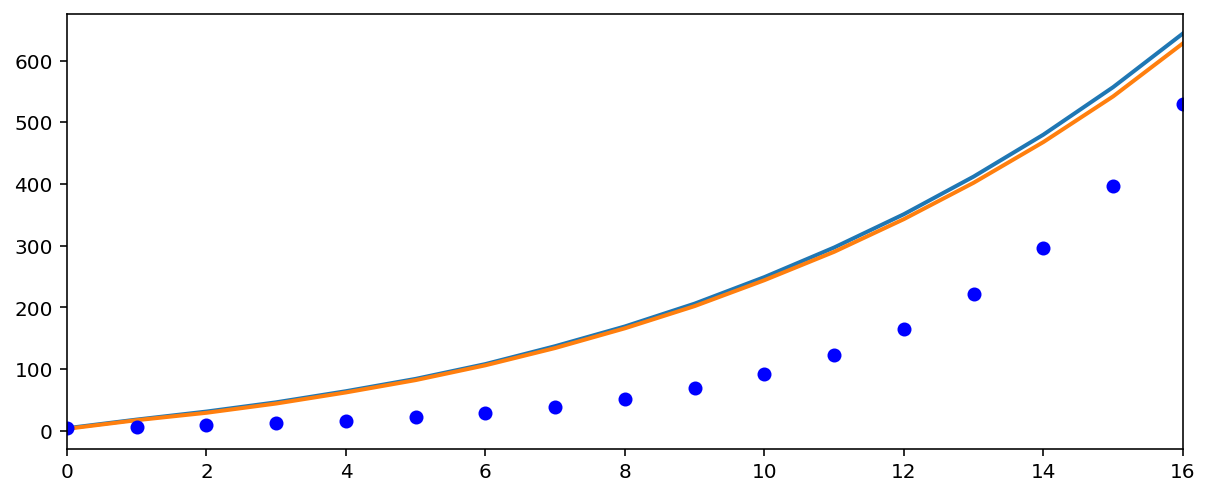

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(x, brightness_4K_monitor, lw=2.0)
plt.plot(x, brightness_5K_monitor, lw=2.0)
plt.plot(x, f(x, *popt), 'bo')
plt.autoscale(axis="x", tight=True)
plt.show()

In [15]:
mbp_fit_np = np.round(f(x, *popt))

## `b` and `c`

In [16]:
def f(x, b, c):
    return np.exp(b * x) + c
popt, pcov = curve_fit(f, x_mbp, brightness_mbp)
popt

/Users/ilirium/opt/anaconda3/envs/geo_structured/lib/python3.7/site-packages/scipy/optimize/minpack.py:808: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


array([0.39158133, 4.        ])

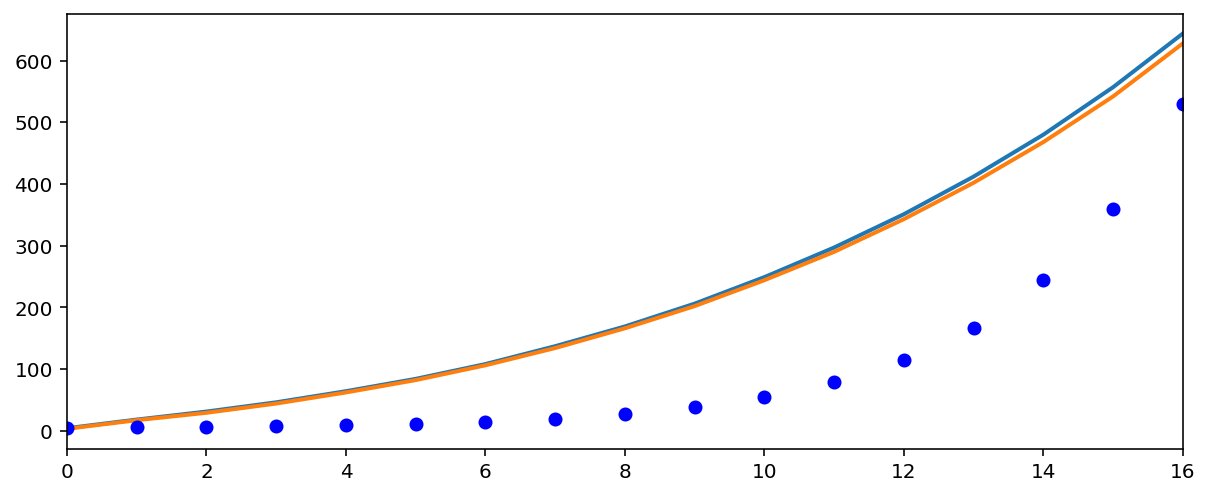

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(x, brightness_4K_monitor, lw=2.0)
plt.plot(x, brightness_5K_monitor, lw=2.0)
plt.plot(x, f(x, *popt), 'bo')
plt.autoscale(axis="x", tight=True)
plt.show()

## `a` and `c`

In [18]:
def f(x, a, c):
    return a * np.exp(x) + c
popt, pcov = curve_fit(f, x_mbp, brightness_mbp)
popt

/Users/ilirium/opt/anaconda3/envs/geo_structured/lib/python3.7/site-packages/scipy/optimize/minpack.py:808: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


array([5.90809734e-05, 4.99994092e+00])

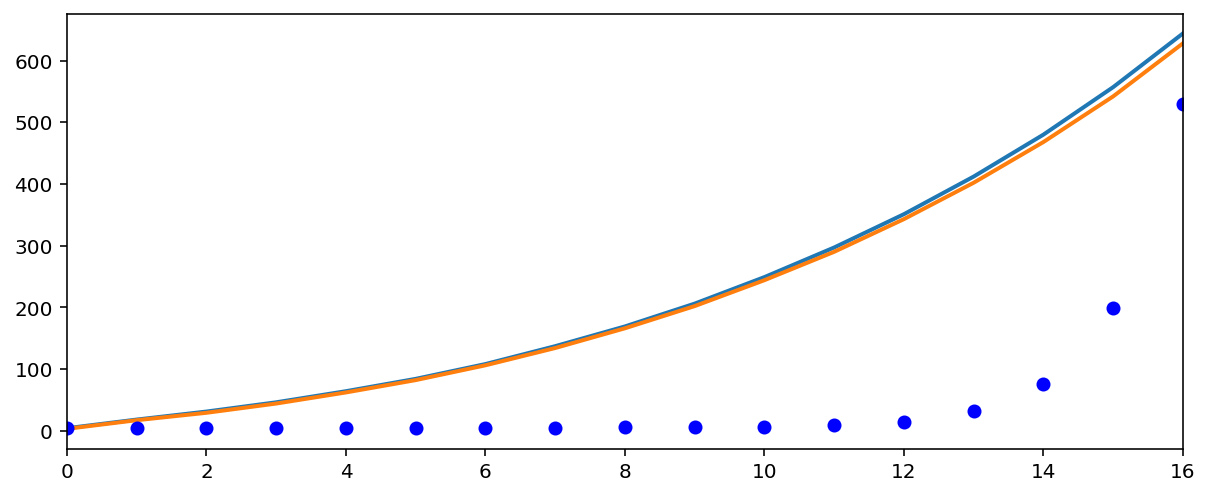

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(x, brightness_4K_monitor, lw=2.0)
plt.plot(x, brightness_5K_monitor, lw=2.0)
plt.plot(x, f(x, *popt), 'bo')
plt.autoscale(axis="x", tight=True)
plt.show()

# Compare

In [20]:
df = pd.DataFrame({'brightness_4K': brightness_4K_monitor,
                   'brightness_5K': brightness_5K_monitor,
                   'brightness_mbp': mbp_fit_np})
df

,brightness_4K,brightness_5K,brightness_mbp
0,4,3,5.0
1,18,17,7.0
2,31,29,9.0
3,46,44,12.0
4,64,62,16.0
5,84,82,21.0
6,108,106,29.0
7,137,134,38.0
8,169,166,51.0
9,206,202,69.0
